# Análisis de actividad de PostgreSQL / Joomla
Este cuaderno se conecta a la base de datos `database` (PostgreSQL) del stack y muestra la actividad reciente de conexiones.

In [2]:
!pip install -q psycopg2-binary pandas matplotlib sqlalchemy

In [3]:
import os
import pandas as pd
from sqlalchemy import create_engine

DB_HOST = os.environ.get('POSTGRES_HOST', 'database')
DB_NAME = os.environ.get('POSTGRES_DB', 'joomladb')
DB_USER = os.environ.get('POSTGRES_USER', 'joomlauser')
DB_PASS = os.environ.get('POSTGRES_PASSWORD', 'joomlapass123')

engine = create_engine(f'postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:5432/{DB_NAME}')
print('Conexión creada hacia', DB_HOST)

Conexión creada hacia database


In [4]:
query = """
SELECT pid, usename, client_addr, state, backend_start, query
FROM pg_stat_activity
WHERE datname = current_database()
ORDER BY backend_start DESC;
"""
df = pd.read_sql(query, engine)
df

,pid,usename,client_addr,state,backend_start,query
0,2873,joomlauser,172.18.0.2,active,2026-09-22 21:57:15.751727+00:00,"\nSELECT pid, usename, client_addr, state, bac..."


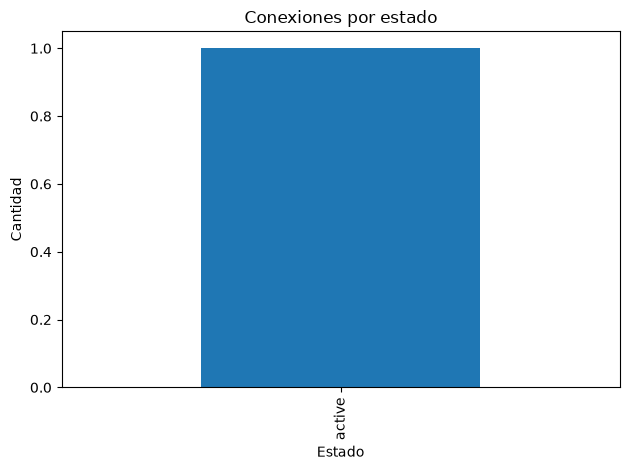

In [5]:
import matplotlib.pyplot as plt

conteo_por_estado = df['state'].value_counts()
conteo_por_estado.plot(kind='bar', title='Conexiones por estado')
plt.xlabel('Estado')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

In [6]:
!pip install -q --upgrade sqlalchemy pandas psycopg2-binary 